# Task 1: Data Exploration and Visualization 

In [1]:
#Importing important tools for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#loading training and testing dataset
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

print(df_train.head()) #to check the first 5 rows of the training dataset
print("\n")
print(df_train.info()) #to check the data types and non-null values in the training dataset
print("\n")
print(df_train.describe()) #to get the statistical summary of the training dataset

                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


<class 'pandas.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    288000 non-null  str  
 1   rating  288000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 4.4 MB
None


              rating
count  288000.000000
mean        2.612115
std         1.472543
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000


In [2]:
#checking for unique values in the 'rating' column
print("Unique values in 'rating' column:", np.sort(df_train['rating'].unique()))
#checking for missing values in the training dataset
print("Missing values in training dataset:\n", df_train.isnull().sum())
#checking the dimensions of the training dataset
print("dataset dimensions:", df_train.shape)

Unique values in 'rating' column: [1 2 3 4 5]
Missing values in training dataset:
 text      0
rating    0
dtype: int64
dataset dimensions: (288000, 2)


In [3]:
print("null values:")#to check for null values in the training dataset
print("duplicated values:", df_train.duplicated().sum())#to check for duplicated values in the training dataset

null values:
duplicated values: 0



Distribution of rating:
mean: 2.61
median: 3.00
mode: 1
std: 1.47
min: 1
max: 5
skewness: 0.15995527920064573


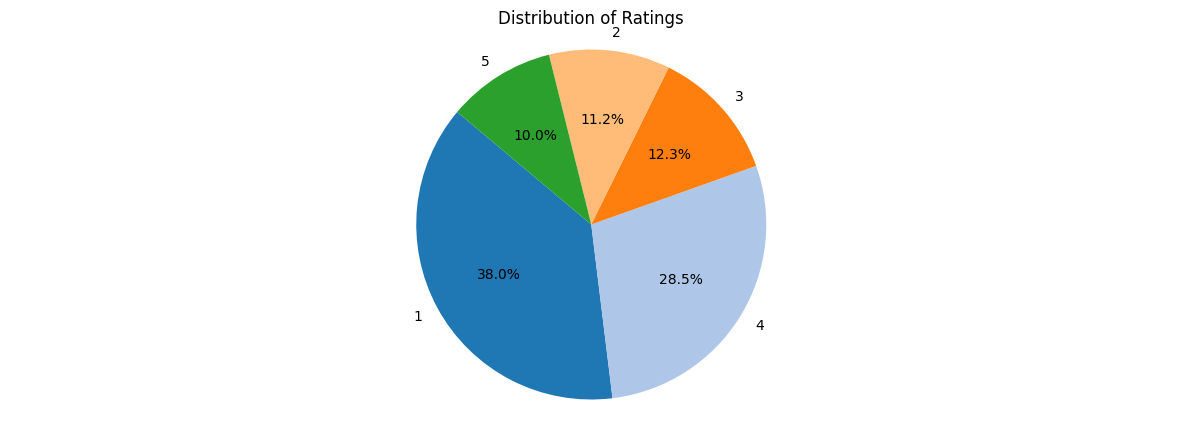

In [4]:
#rating distribution
rating_col = ['rating'] #list of columns to analyze for rating distribution
for col in rating_col: #iterating through the list of columns to analyze
    if col in df_train.columns: #checking if the column exists in the training dataset
        print(f"\nDistribution of {col}:") #to print the distribution of the column
        print(f"mean: {df_train[col].mean():.2f}") #to print the mean of the column rounded to 2 decimal places
        print(f"median: {df_train[col].median():.2f}") #to print the median of the column rounded to 2 decimal places
        print(f"mode: {df_train[col].mode()[0]}") #to print the mode of the column (the most frequent value)
        print(f"std: {df_train[col].std():.2f}") #to print the standard deviation of the column rounded to 2 decimal places
        print(f"min: {df_train[col].min()}") #to print the minimum value of the column
        print(f"max: {df_train[col].max()}") #to print the maximum value of the column
        print(f"skewness: {df_train[col].skew()}") #to print the skewness of the column (a measure of the asymmetry of the distribution)
    
#rating distribution plot
rating_counts = df_train['rating'].value_counts() #to count the occurrences of each unique value in the 'rating' column
plt.figure(figsize=(15, 5)) #to set the figure size for the plot
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Ratings')
plt.show()

In [5]:
print("TEXT LENGTH STATISTICS FOR DF:")
df_train['text_length'] = df_train['text'].str.len() #to create a new column 'text_length' that contains the length of the text in each row of the 'text' column
print(df_train['text_length'].describe())#to get the statistical summary of the 'text_length' column

TEXT LENGTH STATISTICS FOR DF:
count    288000.000000
mean        315.545288
std         427.792476
min          10.000000
25%          70.000000
50%         173.000000
75%         385.000000
max        8049.000000
Name: text_length, dtype: float64


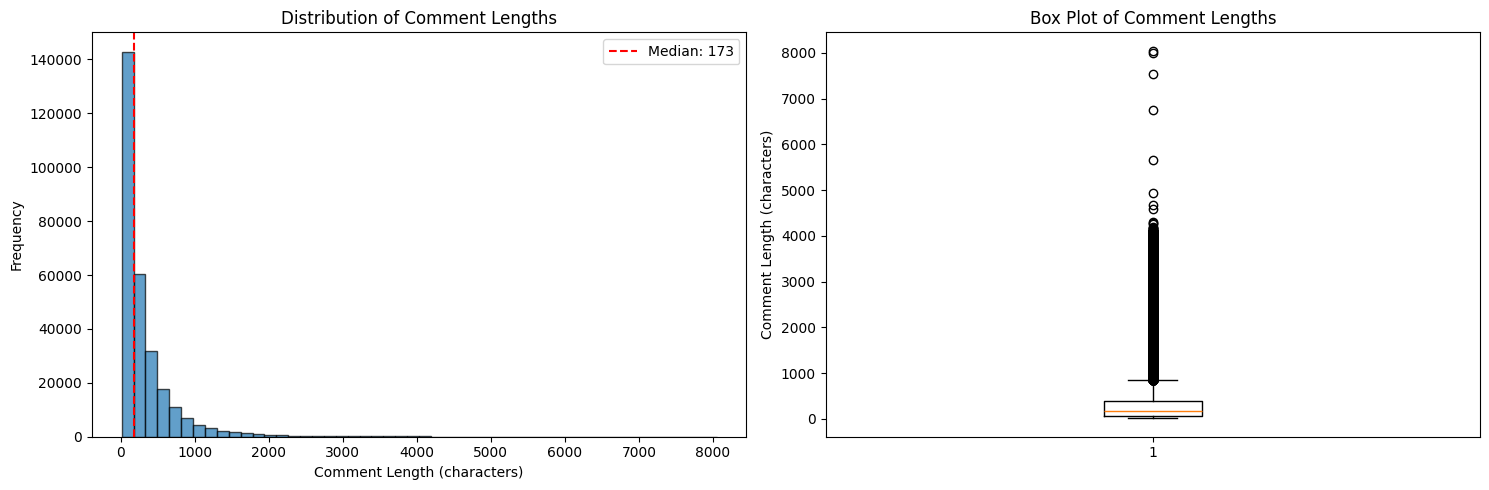

In [6]:
#visualization of the distribution of comment lengths using a histogram and a box plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Histogram
axes[0].hist(df_train['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Comment Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Comment Lengths')
axes[0].axvline(df_train['text_length'].median(), color='red', linestyle='--', label=f'Median: {df_train["text_length"].median():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_train['text_length'], vert=True)
axes[1].set_ylabel('Comment Length (characters)')
axes[1].set_title('Box Plot of Comment Lengths')

plt.tight_layout()
plt.show()

In [7]:
# Insights from plots
print("INSIGHTS:")
print(f"   - Median length of coments: {df_train['text_length'].median():.0f} characters")#to print the median length of comments rounded to 0 decimal places
print(f"   - Very short comments (<20 chars): {(df_train['text_length'] < 20).sum():,}") #to print the number of comments that are very short (less than 20 characters) with comma as a thousand separator
print(f"   - Very long comments (>500 chars): {(df_train['text_length'] > 500).sum():,}") #to print the number of comments that are very long (greater than 500 characters) with comma as a thousand separator

INSIGHTS:
   - Median length of coments: 173 characters
   - Very short comments (<20 chars): 9,692
   - Very long comments (>500 chars): 52,025


In [8]:
df_clean = df_train.copy() # Create a copy of the original DataFrame to perform cleaning operations on, preserving the original data for reference and comparisons. 
initial_count = len(df_clean) # Save initial count for comparisons

print("Starting data cleaning") 
print(f"Initial dataset size: {initial_count:,} comments") #to print the initial size of the dataset with comma as a thousand separator

Starting data cleaning
Initial dataset size: 288,000 comments


In [ ]:
# Update length column to characters instead of words
df_train['review_length'] = df_train['text'].apply(lambda x: len(str(x)))

# Show examples of very short reviews
short_reviews = df_train[df_train['review_length'] < 20][['text', 'rating', 'review_length']].head(5)
print("Examples of reviews under 20 characters:")
print(short_reviews.to_string(index=False))

# Show threshold impact
for threshold in [10, 20, 50]:
    removed = len(df_train_data[df_train_data['review_length'] < threshold])
    pct = (removed / len(df_train_data)) * 100
    print(f"  Threshold < {threshold} chars: {removed} reviews removed ({pct:.1f}%)")

In [9]:
min_length = 20 # define minumum length
df_clean = df_clean[df_train['text_length'] >= min_length] # set the dataset for that only entried greater than 20 are saved 
print(f"\n Removed {initial_count - len(df_clean):,} comments shorter than {min_length} characters") # Compare intial and updated df's
print(f" Remaining: {len(df_clean):,} comments")


 Removed 9,692 comments shorter than 20 characters
 Remaining: 278,308 comments


In [10]:
before_dedup = len(df_clean) # save current number of entires for comparison purposes
df_clean = df_clean.drop_duplicates(subset='text', keep='first') # Remove duplicate comments based on the 'text' column, keeping only the first occurrence of each unique comment. This helps to reduce redundancy in the dataset and ensures that each comment is unique for analysis.
print(f"\n Removed {before_dedup - len(df_clean):,} duplicate comments")
print(f" Remaining: {len(df_clean):,} comments")


 Removed 0 duplicate comments
 Remaining: 278,308 comments


In [11]:
import langid # Importing the langid library for language detection, which will be used to filter out non-English comments from the dataset.
def is_english(text): # Define a function to check if the text is in English using langid's classify method, which returns the detected language and its confidence score. 
    try:
        lang, _ = langid.classify(str(text))#Convert the input text to a string to ensure compatibility with langid, 
        return lang == 'en' #and classify it to get the detected language code (e.g., 'en' for English). The function returns True if the detected language is English, and False otherwise. 
    except:
        return False  # Drop rows where detection fails

# Apply the filter
train_df = df_clean[df_clean['text'].apply(is_english)].reset_index(drop=True)
# Check how many rows were removed
print(f"Training set: {len(train_df)} rows remaining")
# Save the cleaned datasets
train_df.to_csv('train_english.csv', index=False)


Training set: 271897 rows remaining


In [12]:
test_df = pd.read_csv('data/test.csv')# Load the test dataset from the specified CSV file into a DataFrame called test_df.
test_df = test_df[test_df['text'].apply(is_english)].reset_index(drop=True)# Apply the same English language filter to the test dataset, keeping only rows where the 'text' column is detected as English. The index is reset after filtering to maintain a clean sequential index.
print(f"Test set: {len(test_df)} rows remaining")
test_df.to_csv('test_english.csv', index=False)# Save the cleaned test dataset to a new CSV file named 'test_english.csv', without including the index in the output file.

Test set: 69907 rows remaining


In [13]:
# Further cleaning: Removing entries that do not contain any alphabetic characters (e.g., only numbers or symbols)
import re
train_df = pd.read_csv('data/train_english.csv') # Load the cleaned training dataset from the specified CSV file into a DataFrame called train_df.
test_df = pd.read_csv('data/test_english.csv') # Load the cleaned test dataset from the specified CSV file into a DataFrame called test_df.

train_df = train_df.dropna(subset=['text']).reset_index(drop=True) # Remove rows from the training dataset where the 'text' column contains null values, and reset the index of the DataFrame after dropping these rows to maintain a clean sequential index.
test_df = test_df.dropna(subset=['text']).reset_index(drop=True) # Remove rows from the test dataset where the 'text' column contains null values, and reset the index of the DataFrame after dropping these rows to maintain a clean sequential index.

# Remove rows where 'text' is empty or contains only whitespace
train_df = train_df[train_df['text'].str.strip() != ''] 
test_df = test_df[test_df['text'].str.strip() != '']

# Remove rows where 'text' does not contain any alphabetic characters using a regular expression to check for the presence of letters (both uppercase and lowercase). This helps to ensure that the dataset contains meaningful text data for analysis and modeling.
train_df = train_df[train_df['text'].apply(lambda x: bool(re.search(r'[a-zA-Z]', str(x))))]
test_df = test_df[test_df['text'].apply(lambda x: bool(re.search(r'[a-zA-Z]', str(x))))]

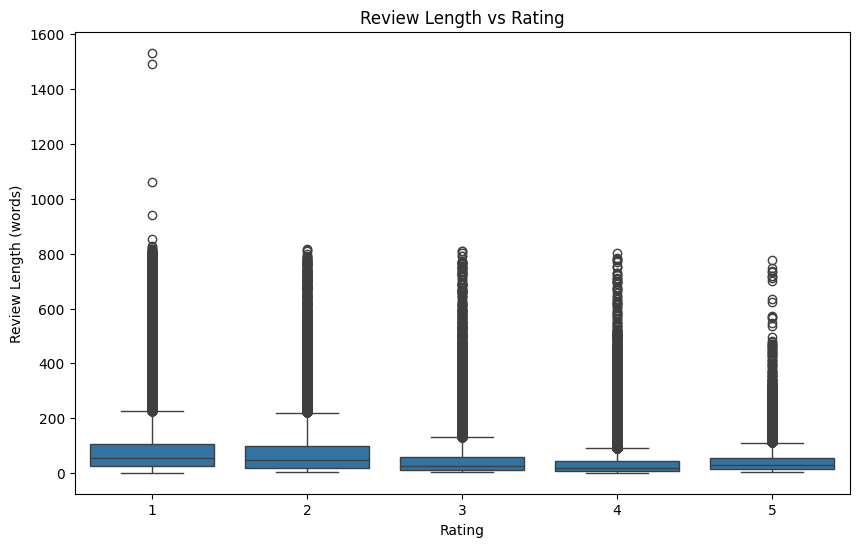

In [14]:
# After cleaning, we can visualize the relationship between review length and rating to see if there are any patterns or trends. This can help us understand if longer reviews tend to have higher or lower ratings, or if there is no clear relationship between the two variables.
import matplotlib.pyplot as plt
import seaborn as sns

# Add review length column
train_df['review_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='review_length', data=train_df)
plt.title('Review Length vs Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length (words)')
plt.show()

In [15]:
#Get top words for each rating category
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Define a set of stop words to exclude from the analysis, which includes common English words that may not carry significant meaning 
stop_words = set(stopwords.words('english'))
# We can also add some custom stop words that are frequently used in reviews but may not provide useful insights.
custom_stopwords = stop_words.union({'get', 'one', 'go', 'like', 'got', 'even', 'back', 'would', 'could', 'also'})

def get_top_words(df, rating, n=20): # Define a function to get the top n most common words for a given rating category. 
    texts = df[df['rating'] == rating]['text'].str.cat(sep=' ')# Concatenate all the text entries for the specified rating category into a single string, separating them with a space. 
    words = [w.lower() for w in texts.split() if w.lower() not in custom_stopwords and w.isalpha()]# Split the concatenated text into individual words, convert them to lowercase, and filter out any words that are in the custom stop words set or that are not purely alphabetic 
    return Counter(words).most_common(n)

for r in sorted(train_df['rating'].unique()):# Iterate through each unique rating in the training dataset, sorted in ascending order, to analyze the top words associated with each rating category.
    print(f"\nRating {r}: {get_top_words(train_df, r)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Rating 1: [('never', 27584), ('told', 26754), ('time', 22777), ('said', 21687), ('called', 19146), ('place', 18545), ('call', 16721), ('service', 16558), ('people', 14811), ('went', 14447), ('customer', 13995), ('asked', 12553), ('going', 12368), ('give', 12039), ('company', 12026), ('still', 12004), ('take', 11979), ('know', 11945), ('work', 11506), ('another', 11285)]

Rating 2: [('time', 6647), ('told', 5498), ('never', 4849), ('place', 4653), ('good', 4515), ('said', 4448), ('service', 4439), ('went', 3757), ('called', 3685), ('people', 3666), ('staff', 3645), ('going', 3372), ('call', 3351), ('really', 3188), ('first', 3133), ('still', 3109), ('work', 3098), ('two', 3022), ('asked', 2973), ('know', 2964)]

Rating 3: [('good', 5857), ('place', 4326), ('time', 4262), ('nice', 3734), ('great', 3487), ('service', 3452), ('staff', 3187), ('really', 2810), ('people', 2589), ('food', 2513), ('told', 2262), ('work', 2235), ('never', 2141), ('little', 2087), ('need', 2070), ('went', 2059)

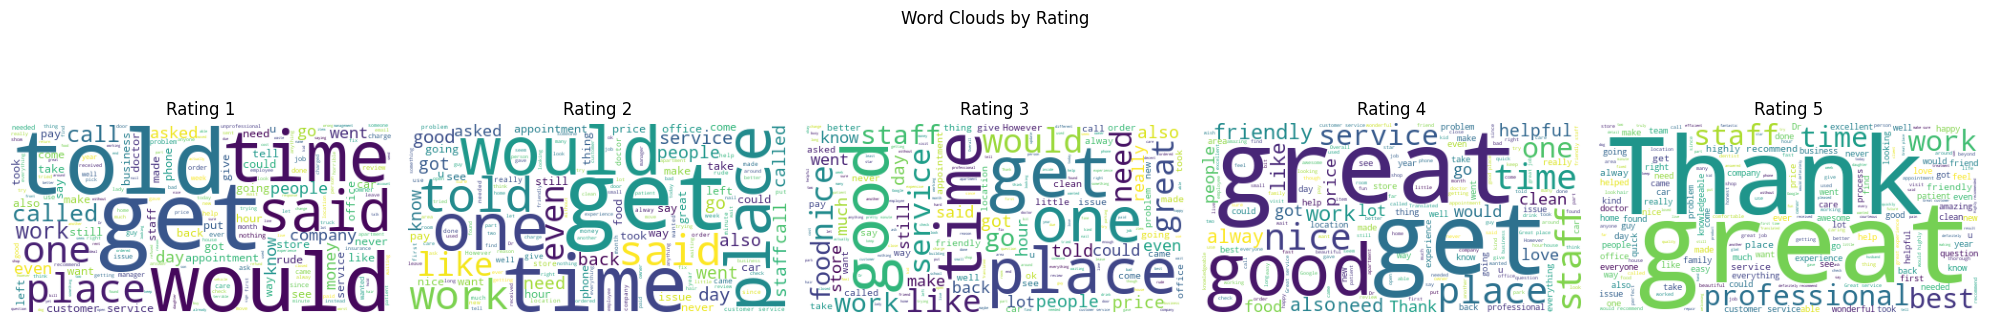

In [16]:
#plot word clouds for each rating category

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, rating in enumerate(sorted(train_df['rating'].unique())):
    text = train_df[train_df['rating'] == rating]['text'].str.cat(sep=' ')
    wc = WordCloud(stopwords=stop_words, background_color='white').generate(text)
    axes[i].imshow(wc)
    axes[i].set_title(f'Rating {rating}')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Rating')
plt.tight_layout()
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


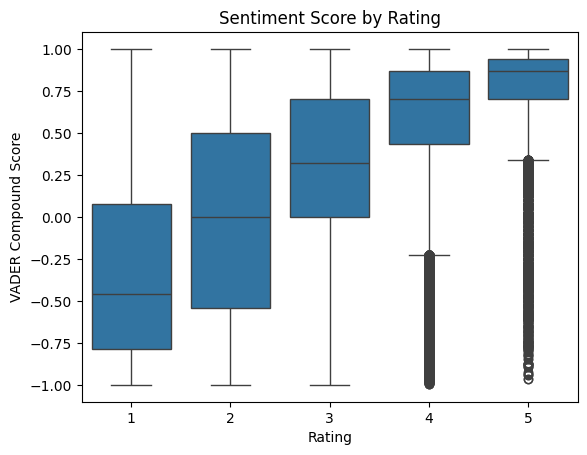

In [17]:
# To analyze the sentiment of the reviews, we can use the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis tool from the NLTK library. This will allow us to calculate a sentiment score for each review and see how it correlates with the ratings.
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

#Initialize the VADER sentiment analyzer and apply it to the 'text' column of the training dataset to calculate a compound sentiment score for each review. The compound score is a normalized, weighted composite score that ranges from -1 (most negative) to +1 (most positive). We then create a new column 'sentiment_score' in the DataFrame to store these scores for further analysis and visualization.
sia = SentimentIntensityAnalyzer()
train_df['sentiment_score'] = train_df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

#Plot the distribution of sentiment scores for each rating category using a box plot to visualize how the sentiment scores vary across different ratings. This can help us understand if higher ratings tend to have more positive sentiment scores and if lower ratings tend to have more negative sentiment scores, as well as the overall spread and outliers in the sentiment scores for each rating category.
sns.boxplot(x='rating', y='sentiment_score', data=train_df)
plt.title('Sentiment Score by Rating')
plt.xlabel('Rating')
plt.ylabel('VADER Compound Score')
plt.show()

In [18]:
print("CLEANING SUMMARY")

print(f"Started with: {initial_count:,} comments")
print(f"Cleaned dataset: {len(train_df):,} comments")
print(f"Removed: {initial_count - len(train_df):,} comments ({((initial_count - len(train_df))/initial_count*100):.1f}%)")
print(f"Retained:{(len(train_df)/initial_count*100):.1f}%")

CLEANING SUMMARY
Started with: 288,000 comments
Cleaned dataset: 271,897 comments
Removed: 16,103 comments (5.6%)
Retained:94.4%


In [19]:
for i, (idx, row) in enumerate(train_df.sample(5).iterrows(), 1):
    
    print(f"\n--- Sample {i} ---")
    
    print(f"Rating: {row['rating']}")
    
    print(f"Length: {row['text_length']} characters")
    
    print(f"Text: {row['text'][:200]}")
    print()


--- Sample 1 ---
Rating: 4
Length: 26 characters
Text: Tasty apps and peroni beer


--- Sample 2 ---
Rating: 4
Length: 142 characters
Text: All four of my children receive dental and orthodontic work through bright Now dental... we are pleased with their services and friendly staff


--- Sample 3 ---
Rating: 4
Length: 134 characters
Text: Very honest services regarding my care, fair prices, & informed me on future dental needs. I felt safe,  comfortable, & would go back.


--- Sample 4 ---
Rating: 2
Length: 951 characters
Text: Absolute chaotic mess.  They locked us into leases by informing us one week before, on August 13, that they were greatly "surprised" that the apartments wouldn't be complete by August 20, the day our 


--- Sample 5 ---
Rating: 2
Length: 45 characters
Text: Closed on a Saturday at 10pm ...disappointing




 Review Rating Distribution:
   1 stars: 105,783 reviews (38.9%)
   2 stars: 30,876 reviews (11.4%)
   3 stars: 32,404 reviews (11.9%)
   4 stars: 75,242 reviews (27.7%)
   5 stars: 27,592 reviews (10.1%)

 Sentiment Categories:
   Negative: 136,659 reviews (50.3%)
   Positive: 102,834 reviews (37.8%)
   Neutral: 32,404 reviews (11.9%)


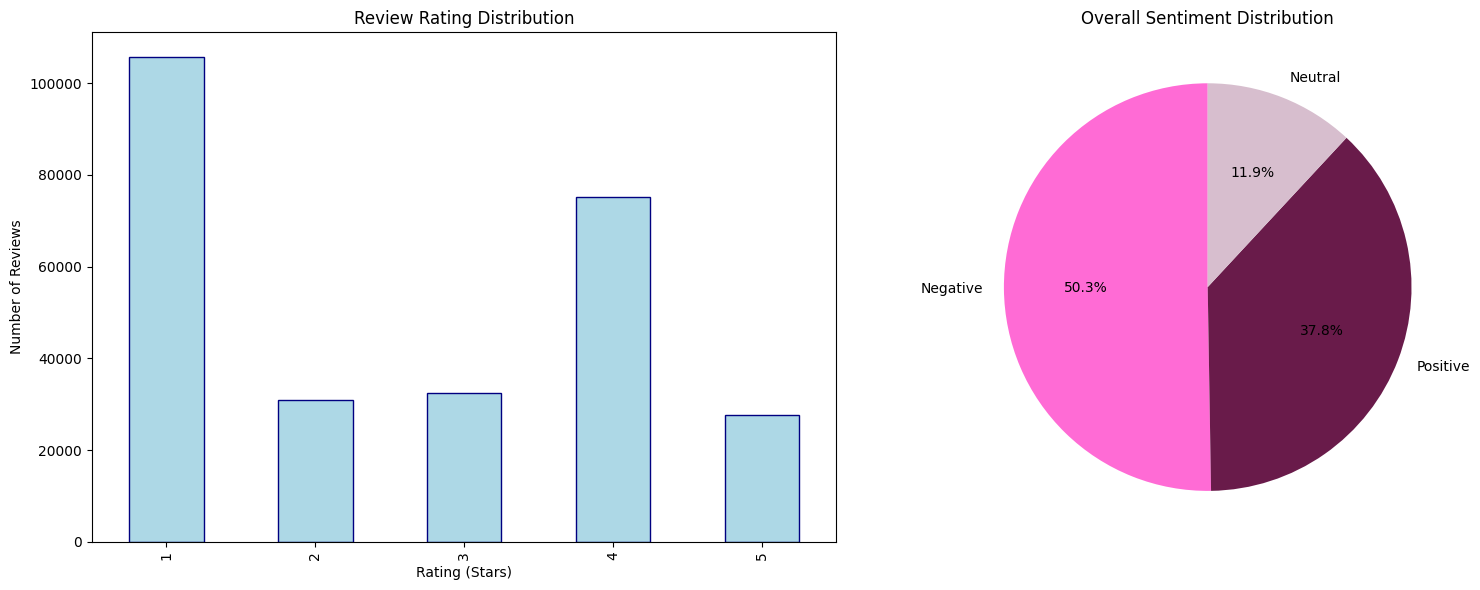

In [20]:
# Rating distribution analysis
rating_distribution = train_df['rating'].value_counts().sort_index()
print("\n Review Rating Distribution:")
for rating, count in rating_distribution.items():
    percentage = (count / len(train_df)) * 100 #Calculate the percentage of reviews for each rating category 
    print(f"   {rating} stars: {count:,} reviews ({percentage:.1f}%)")

# Sentiment categorization based on VADER compound scores, where we classify reviews with a rating of 1 or 2 as 'Negative', a rating of 3 as 'Neutral', and ratings of 4 or 5 as 'Positive'. This categorization allows us to analyze the overall sentiment distribution in the dataset and see how it correlates with the star ratings.
def categorize_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'
# Apply the categorization function to create a new column 'sentiment_category' in the training DataFrame, which will contain the sentiment category ('Negative', 'Neutral', or 'Positive') corresponding to each review based on its rating. We then calculate the distribution of these sentiment categories to understand the overall sentiment landscape of the reviews in the dataset.
train_df['sentiment_category'] = train_df['rating'].apply(categorize_sentiment)
sentiment_dist = train_df['sentiment_category'].value_counts()

print(f"\n Sentiment Categories:")#to print the distribution of sentiment categories in the dataset, showing the count and percentage of reviews that fall into each category (Negative, Neutral, Positive) based on their ratings.
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(train_df)) * 100
    print(f"   {sentiment}: {count:,} reviews ({percentage:.1f}%)")

# Visualize sentiment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Rating distribution
rating_distribution.plot(kind='bar', ax=ax1, color='lightblue', edgecolor='navy')
ax1.set_title('Review Rating Distribution')
ax1.set_xlabel('Rating (Stars)')
ax1.set_ylabel('Number of Reviews')

# Sentiment pie chart
colors = ["#FF6BD5", "#691B4A", "#D7BECE"]
sentiment_dist.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Overall Sentiment Distribution')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()